In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 1200)

DATA_PATH = "../data/raw/bank_churn.csv"
TARGET_COL = "Exited"

In [12]:
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully.
Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Important input columns: CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary

Output column: Exited

In [13]:
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Column names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


0 null values

Total 10000 rows

In [15]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


Unbalanced dataset, with only 20% of the customers churning. This will require special attention during model training, as it may lead to biased predictions towards the majority class (non-churners).

In [18]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 0


### Relationship with churn

In [ ]:
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Surname', 'Geography', 'Gender']

Numerical columns:
['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


C:\Users\outgl\AppData\Local\Temp\ipykernel_6756\376860241.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


In [ ]:
categorical_cols.remove('Surname')  # Removing 'Surname' as it is not useful for analysis

for col in categorical_cols:
    print(f"\n--- {col} ---")
    summary = pd.crosstab(df[col], df[TARGET_COL], normalize="index") * 100
    print(summary)


--- Geography ---
Exited             0          1
Geography                      
France     83.845233  16.154767
Germany    67.556796  32.443204
Spain      83.326605  16.673395

--- Gender ---
Exited          0          1
Gender                      
Female  74.928461  25.071539
Male    83.544072  16.455928


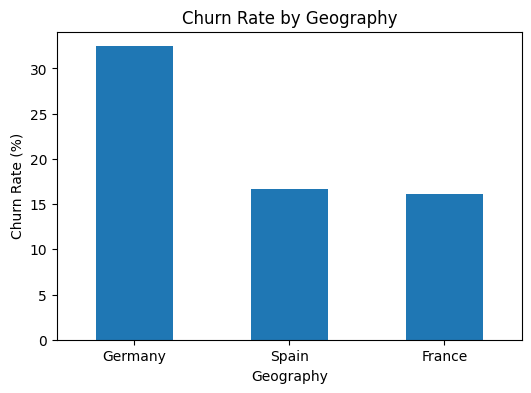

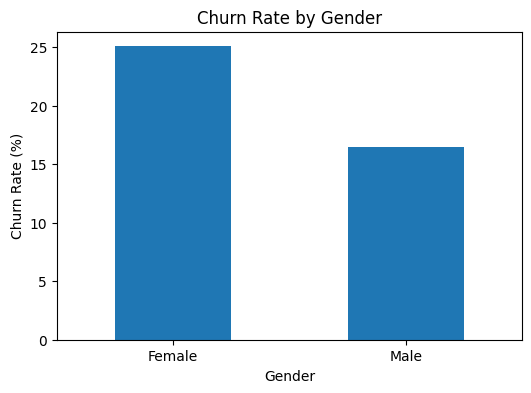

In [24]:
for col in ["Geography", "Gender"]:
    if col in df.columns:
        churn_rate = df.groupby(col)[TARGET_COL].mean().sort_values(ascending=False) * 100
        
        plt.figure(figsize=(6, 4))
        churn_rate.plot(kind="bar")
        plt.title(f"Churn Rate by {col}")
        plt.ylabel("Churn Rate (%)")
        plt.xlabel(col)
        plt.xticks(rotation=0)
        plt.show()

On average Female clients churn more often, also churning is more trendy in Germany. 

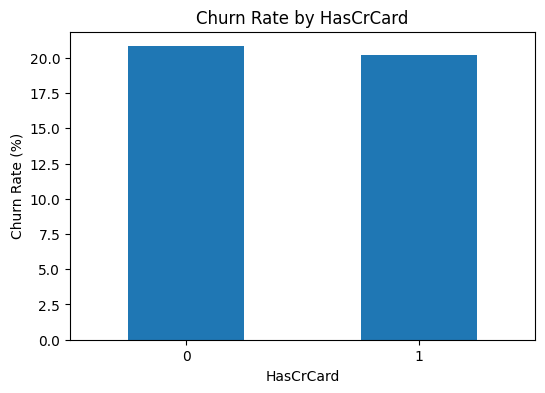

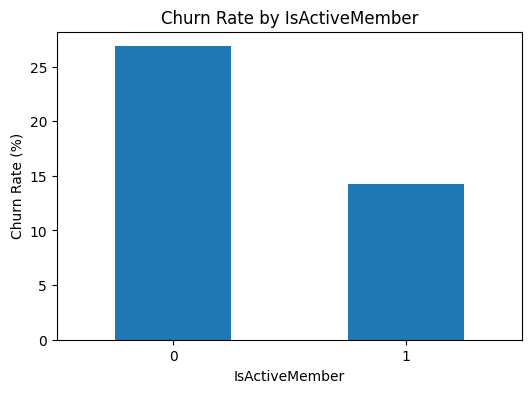

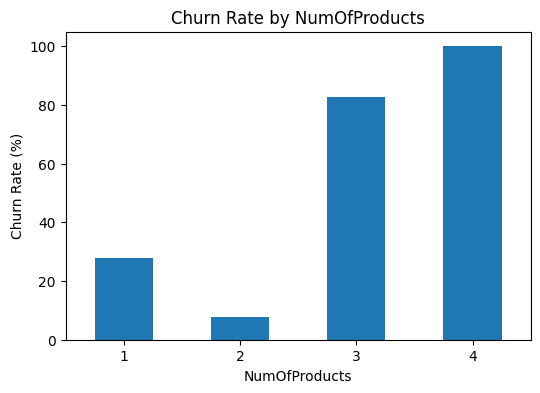

In [25]:
for col in ["HasCrCard", "IsActiveMember", "NumOfProducts"]:
    if col in df.columns:
        churn_rate = df.groupby(col)[TARGET_COL].mean() * 100
        
        plt.figure(figsize=(6, 4))
        churn_rate.plot(kind="bar")
        plt.title(f"Churn Rate by {col}")
        plt.ylabel("Churn Rate (%)")
        plt.xlabel(col)
        plt.xticks(rotation=0)
        plt.show()

It seems credit card has little to now influence on churning.

Moreover, against initial thoughts, the more producs clients have bought the more likely they churn. It is mostly due to the low total amount of clients who bought more than 2 products. We could count those as outliers.
Let us look into the support numbers to detect outliers

In [33]:
for col in ["Geography", "Gender", "IsActiveMember", "NumOfProducts"]:
    if col in df.columns:
        print(f"\n--- {col} counts ---")
        print(df[col].value_counts(dropna=False))


--- Geography counts ---
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

--- Gender counts ---
Gender
Male      5457
Female    4543
Name: count, dtype: int64

--- IsActiveMember counts ---
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

--- NumOfProducts counts ---
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


In [34]:
for col in ["Geography", "Gender", "IsActiveMember", "NumOfProducts"]:
    if col in df.columns:
        print(f"\n--- {col} vs {TARGET_COL} ---")
        print(pd.crosstab(df[col], df[TARGET_COL]))


--- Geography vs Exited ---
Exited        0    1
Geography           
France     4204  810
Germany    1695  814
Spain      2064  413

--- Gender vs Exited ---
Exited     0     1
Gender            
Female  3404  1139
Male    4559   898

--- IsActiveMember vs Exited ---
Exited             0     1
IsActiveMember            
0               3547  1302
1               4416   735

--- NumOfProducts vs Exited ---
Exited            0     1
NumOfProducts            
1              3675  1409
2              4242   348
3                46   220
4                 0    60


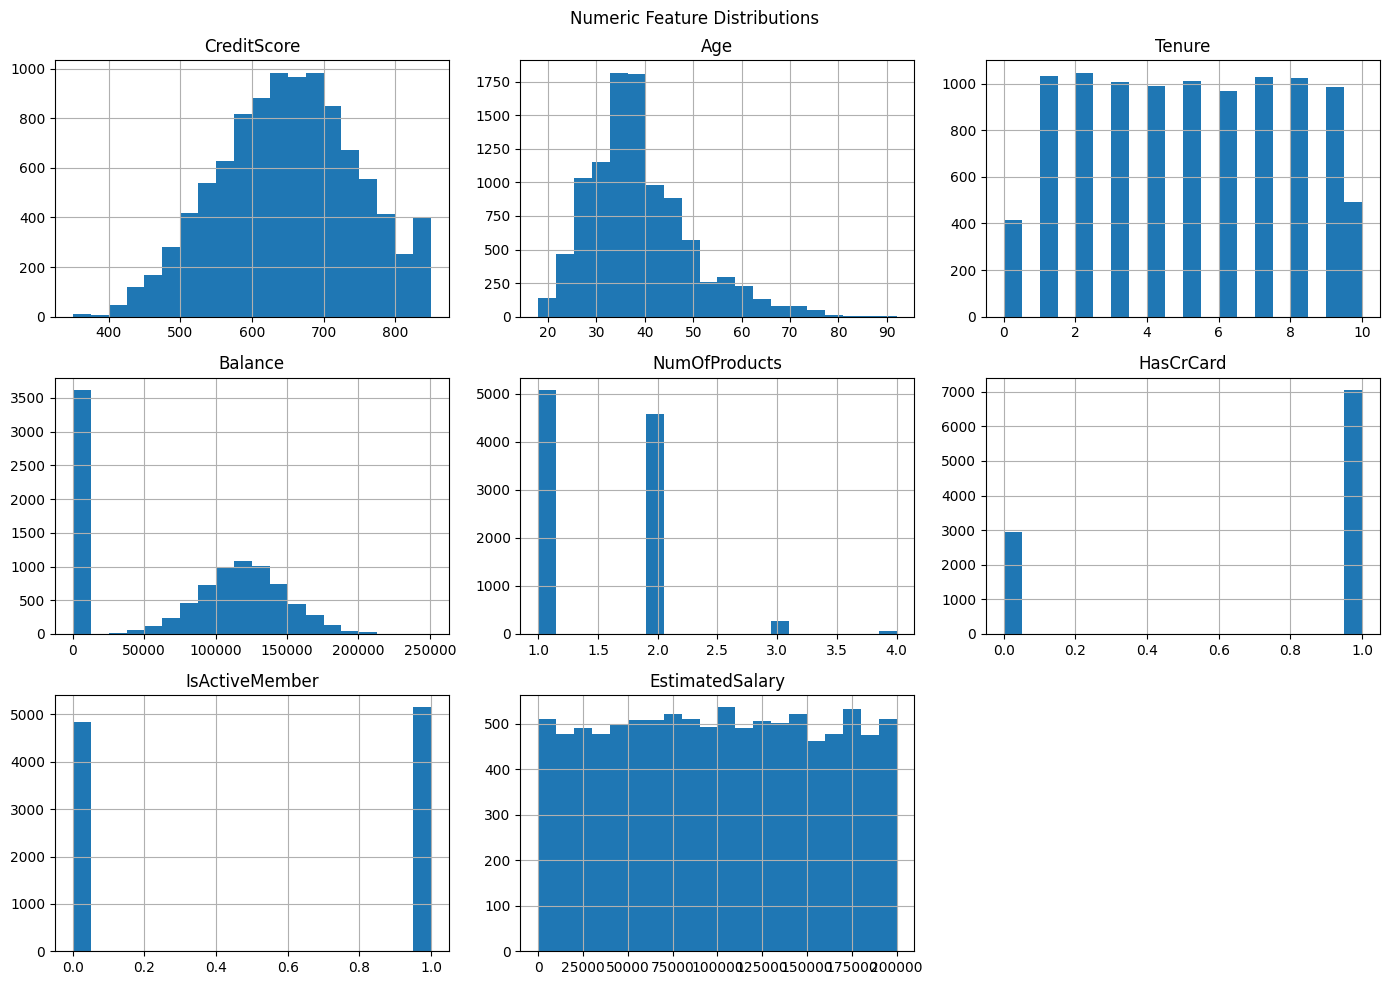

In [28]:
invalid_col = ['CustomerId', 'Surname', 'RowNumber']
numeric_for_plot = [col for col in numerical_cols if (col != TARGET_COL and col not in invalid_col)]

df[numeric_for_plot].hist(figsize=(14, 10), bins=20)
plt.suptitle("Numeric Feature Distributions")
plt.tight_layout()
plt.show()

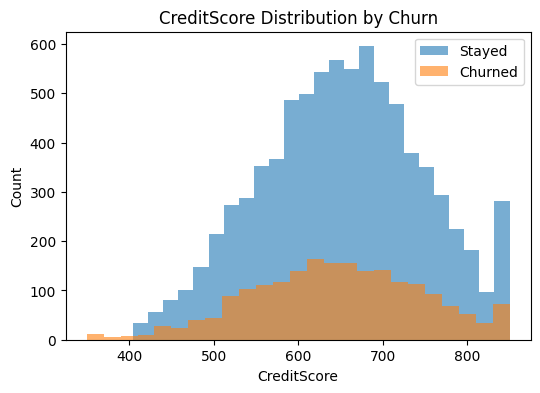

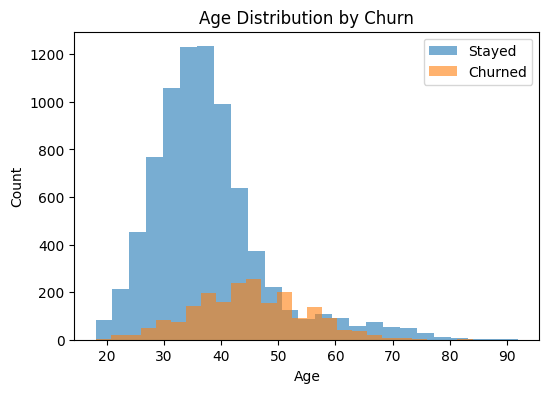

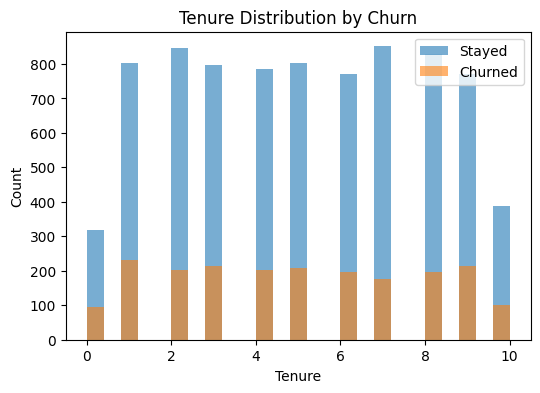

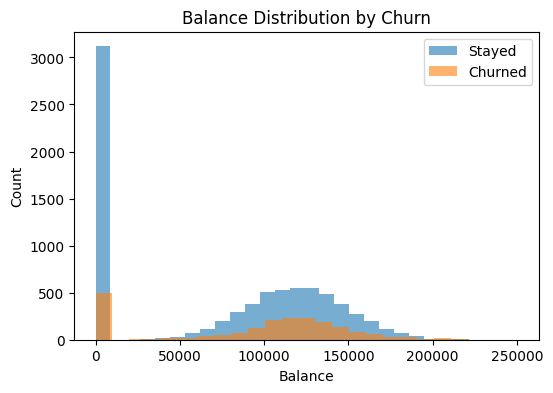

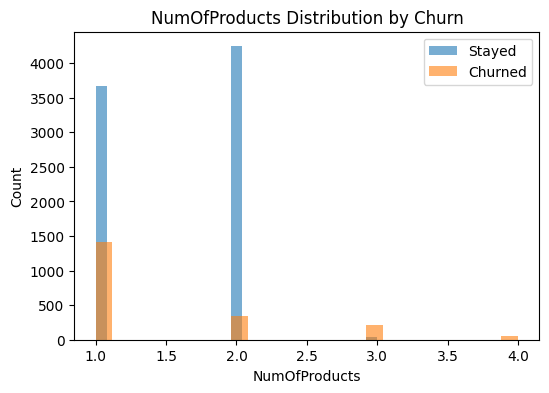

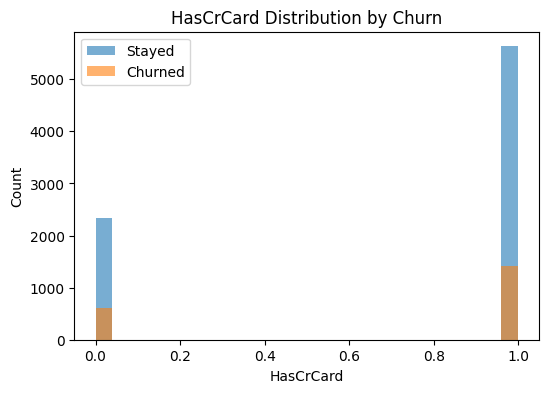

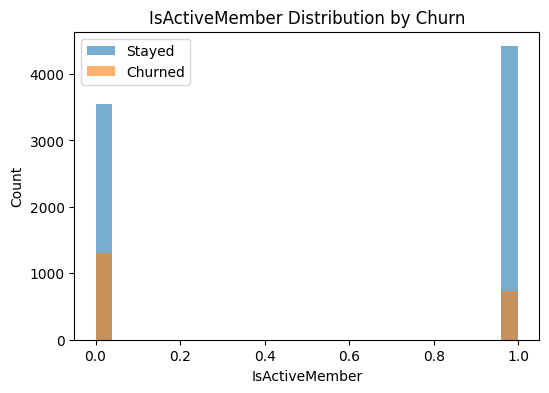

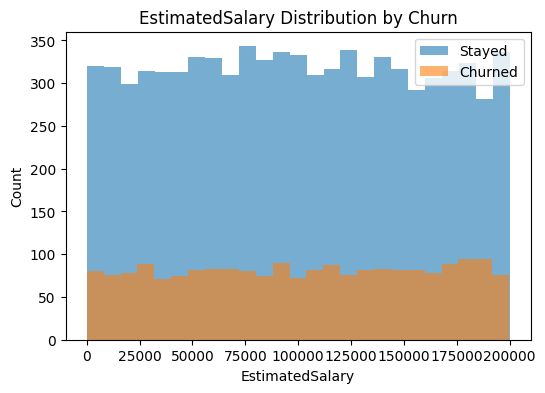

In [29]:
for col in numeric_for_plot:
    plt.figure(figsize=(6, 4))
    plt.hist(df[df[TARGET_COL] == 0][col], bins=25, alpha=0.6, label="Stayed")
    plt.hist(df[df[TARGET_COL] == 1][col], bins=25, alpha=0.6, label="Churned")
    plt.title(f"{col} Distribution by Churn")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

In [30]:
numeric_summary_by_target = df.groupby(TARGET_COL)[numeric_for_plot].mean().T
numeric_summary_by_target.columns = ["Stayed (0)", "Churned (1)"]
numeric_summary_by_target

,Stayed (0),Churned (1)
CreditScore,651.853196,645.351497
Age,37.408389,44.837997
Tenure,5.033279,4.932744
Balance,72745.296779,91108.539337
NumOfProducts,1.544267,1.475209
HasCrCard,0.707146,0.699067
IsActiveMember,0.554565,0.360825
EstimatedSalary,99738.391772,101465.677531


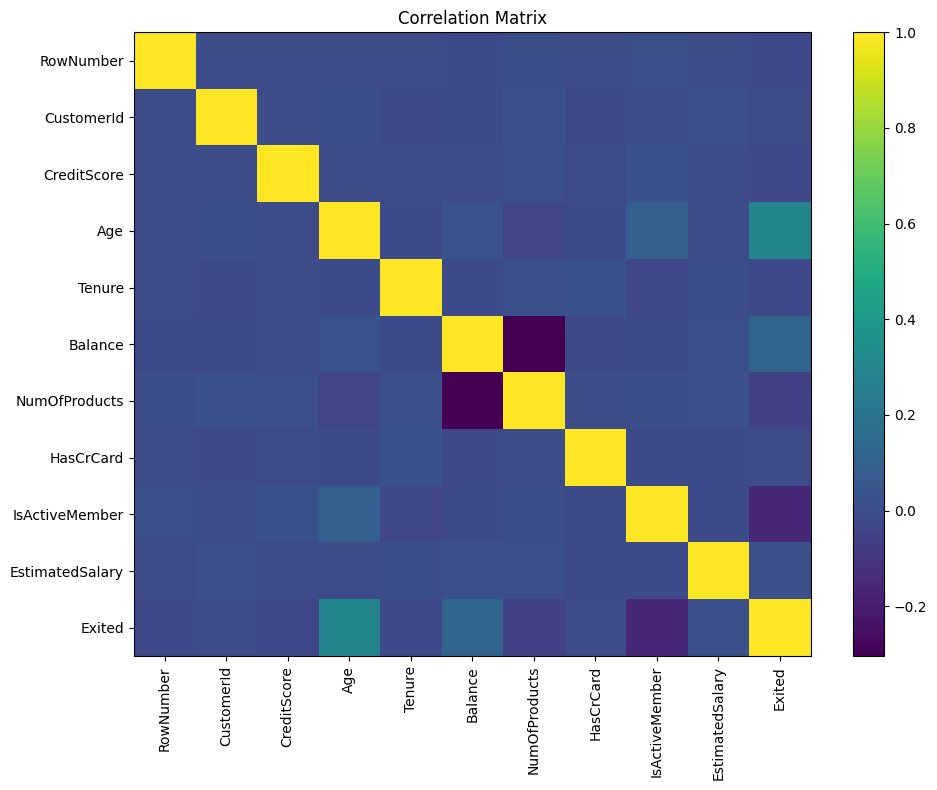

In [31]:
corr = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## EDA Conclusion

The exploratory data analysis shows that the dataset is generally clean and suitable for churn prediction. The target variable, `Exited`, is imbalanced, so model evaluation should rely on metrics such as precision, recall, F1-score, and ROC-AUC rather than accuracy alone.

### Data quality and structure
- The dataset contains a mix of numerical, categorical, binary, and discrete integer features.
- Columns such as `RowNumber`, `CustomerId`, and `Surname` appear to be identifiers or non-predictive attributes and should be excluded from modeling.
- No major structural issues were observed during the initial inspection.
- Some variables, especially `NumOfProducts`, contain highly uneven category frequencies, which must be considered during interpretation.

### Categorical feature findings
- `Geography` appears strongly associated with churn. Customers in **Germany** have a substantially higher churn rate than customers in **France** and **Spain**.
- `Gender` also shows a noticeable relationship with churn, with **female customers** exhibiting a higher churn rate than male customers.
- `IsActiveMember` is one of the strongest predictors observed in the EDA. **Inactive customers** churn at a much higher rate than active customers.
- `HasCrCard` shows only a weak standalone relationship with churn.
- `NumOfProducts` shows a highly non-linear relationship with churn. Customers with **2 products** have the lowest churn rate, while customers with **3 or 4 products** show extremely high churn rates. However, the categories with 3 and 4 products contain relatively few observations, so these extreme values should be interpreted cautiously.

### Numerical feature findings
- `Age` appears to be one of the strongest numerical predictors. Customers who churn tend to be older on average.
- `Balance` also appears informative. Customers with zero balance form a distinct group, while churned customers are more concentrated around moderate-to-high balances.
- `CreditScore` shows some relationship with churn, but the separation between churned and retained customers is weaker than for age or balance.
- `Tenure` does not show a strong standalone effect based on the observed distributions.
- `EstimatedSalary` appears to have little visible relationship with churn.

### Correlation analysis
- The correlation matrix suggests that most pairwise linear relationships with `Exited` are weak to moderate.
- The strongest visible positive association with churn is `Age`.
- `Balance` also shows a positive relationship with churn.
- `IsActiveMember` shows a negative relationship with churn, which is consistent with the earlier categorical analysis.
- `NumOfProducts` appears negatively correlated with churn overall, but this hides the non-linear pattern observed earlier, so simple linear correlation understates its importance.

### Modeling implications
Based on the EDA, the following preprocessing and modeling decisions are justified:
- Drop `RowNumber`, `CustomerId`, and `Surname`.
- Treat `Geography` and `Gender` as categorical variables.
- Retain binary variables such as `HasCrCard` and `IsActiveMember`.
- Keep `NumOfProducts` as an informative feature, but interpret it carefully due to sparse higher categories.
- Prefer models capable of capturing non-linear relationships and feature interactions.
- Evaluate models using metrics appropriate for imbalanced classification problems.

### Final summary
Overall, the EDA suggests that the most informative features for churn prediction are likely to be:
- `Age`
- `IsActiveMember`
- `Geography`
- `Balance`
- `NumOfProducts`

Meanwhile, features such as `EstimatedSalary`, `Tenure`, and likely `HasCrCard` appear weaker on their own, although they may still contribute in combination with other variables.